# Cars Linear Regression: Engine Size vs Price

This notebook uses `scikit-learn` to build a simple linear regression model predicting car **price** from **engine size**, evaluates it with the R² score, and visualizes the relationship with `seaborn`.

## 1. Import Required Libraries

Import pandas for data handling, scikit-learn for the linear regression model and evaluation metrics, and seaborn/matplotlib for visualization.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")

## 2. Load and Inspect the Data

Load `cars.csv` into a DataFrame and take a quick look at the relevant columns (`enginesize` and `price`).

In [23]:
df = pd.read_csv("cars.csv")

print(df.shape)
df[["enginesize", "price"]].describe()

(205, 26)


,enginesize,price
count,205.000000,205.000000
mean,126.907317,13276.710571
std,41.642693,7988.852332
min,61.000000,5118.000000
25%,97.000000,7788.000000
50%,120.000000,10295.000000
75%,141.000000,16503.000000
max,326.000000,45400.000000


## 3. Prepare Features and Target, Split Train/Test

Use `enginesize` as the single feature (X) and `price` as the target (y). Split the data into 80% training and 20% testing sets.

In [24]:
X = df[["enginesize"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 164
Testing samples: 41


## 4. Fit the Linear Regression Model

Train a `LinearRegression` model on the training data.

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Coefficient (slope): 165.84
Intercept: -7741.77


## 5. Evaluate the Model with R²

Predict on both the training and test sets and calculate the R² (coefficient of determination) score for each to see how well engine size explains the variance in price, and to check for overfitting.

In [26]:
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

r2 = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_train_pred)
print(f"R² score on training set: {r2_train:.4f}")
print(f"R² score on test set: {r2:.4f}")

R² score on training set: 0.7507
R² score on test set: 0.8041


## 6. Visualize Engine Size vs Price

Use seaborn to plot engine size against price, distinguishing training and test points, along with the fitted regression line and the R² scores.

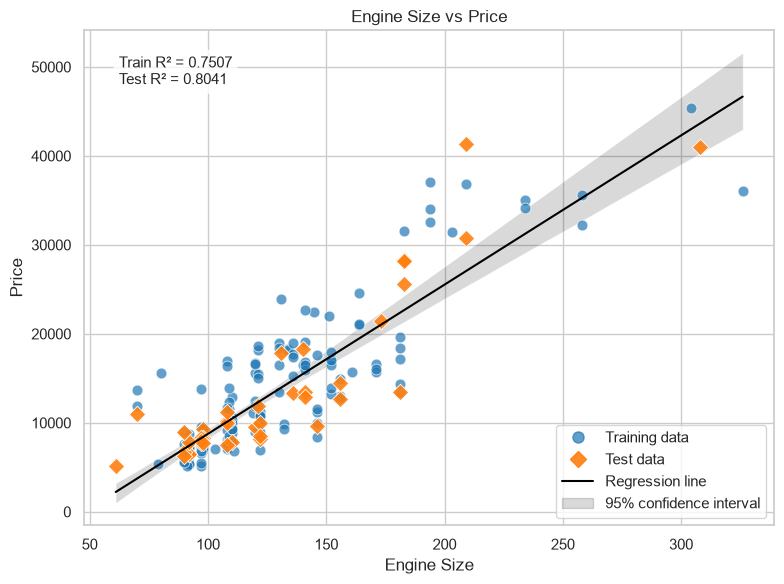

In [27]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="enginesize",
    y="price",
    scatter=False,
    line_kws={"color": "black", "linewidth": 1.5, "label": "Regression line"},
)
sns.scatterplot(
    x=X_train["enginesize"],
    y=y_train,
    color="tab:blue",
    alpha=0.7,
    s=60,
    label="Training data",
)
sns.scatterplot(
    x=X_test["enginesize"],
    y=y_test,
    color="tab:orange",
    alpha=0.9,
    s=70,
    marker="D",
    label="Test data",
)

plt.text(
    0.05,
    0.95,
    f"Train R² = {r2_train:.4f}\nTest R² = {r2:.4f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)

plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")

train_handle = mlines.Line2D(
    [], [], color="tab:blue", marker="o", linestyle="None", markersize=8, alpha=0.7,
    label="Training data",
)
test_handle = mlines.Line2D(
    [], [], color="tab:orange", marker="D", linestyle="None", markersize=8, alpha=0.9,
    label="Test data",
)
line_handle = mlines.Line2D(
    [], [], color="black", linewidth=1.5, label="Regression line",
)
ci_patch = mpatches.Patch(color="black", alpha=0.15, label="95% confidence interval")

plt.legend(
    handles=[train_handle, test_handle, line_handle, ci_patch],
    loc="lower right",
)

plt.tight_layout()
plt.show()